In [2]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

path_red =r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Data\winequality-red.csv"
path_white=r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Data\winequality-white.csv"

Red = pd.read_csv(path_red, sep=";")
White = pd.read_csv(path_white, sep=";")

# 1-TRANSFORMATION DE LA VARIABLE CIBLE

# Pour le vin rouge

In [3]:
# 1 = bonne qualité (>=7), 0 = mauvaise qualité (<7)
Red["quality_label"] = Red["quality"].apply(lambda x: 1 if x >= 7 else 0)

# Vérifions la répartition
print(Red["quality_label"].value_counts(normalize=True))


quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64


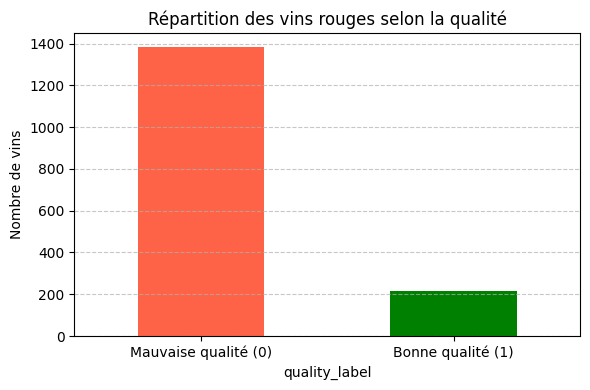

In [4]:
# Histogramme
plt.figure(figsize=(6, 4))
Red["quality_label"].value_counts().sort_index().plot(kind='bar', color=["tomato", "green"])

# Personnalisation des axes
plt.xticks([0, 1], ['Mauvaise qualité (0)', 'Bonne qualité (1)'], rotation=0)
plt.ylabel("Nombre de vins")
plt.title("Répartition des vins rouges selon la qualité")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Pour le vin blanc

In [5]:
# 1 = bonne qualité (>=7), 0 = mauvaise qualité (<7)
White["quality_label"] = White["quality"].apply(lambda x: 1 if x >= 7 else 0)

# Vérifions la répartition
print(White["quality_label"].value_counts(normalize=True))


quality_label
0    0.783585
1    0.216415
Name: proportion, dtype: float64


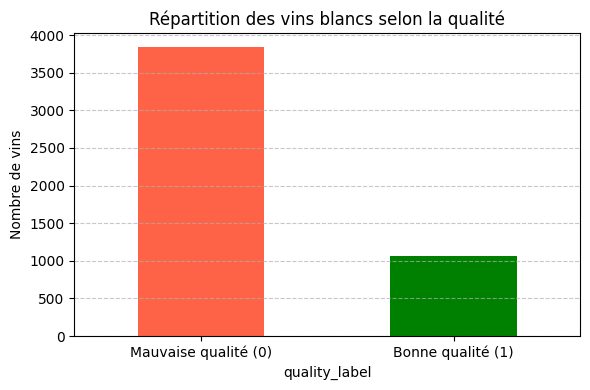

In [6]:
# Histogramme
plt.figure(figsize=(6, 4))
White["quality_label"].value_counts().sort_index().plot(kind='bar', color=["tomato", "green"])

# Personnalisation des axes
plt.xticks([0, 1], ['Mauvaise qualité (0)', 'Bonne qualité (1)'], rotation=0)
plt.ylabel("Nombre de vins")
plt.title("Répartition des vins blancs selon la qualité")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2-MODÉLISATION

# 2-1-Pour le vin rouge

In [7]:
from sklearn.model_selection import train_test_split

# 1) Split avant scaling
X_Red = Red.drop(['quality','quality_label'], axis=1)
y_Red = Red['quality_label']

X_train_Red, X_test_Red, y_train_Red, y_test_Red = train_test_split(
    X_Red, y_Red, test_size=0.20, stratify=y_Red, random_state=42
)

# Pour le moldele simple

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# 2.1) Pipeline simple — fixe ‘alcohol’
pipe_simple_Red = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Pour le moldele multiple

In [9]:
# 2.2) Pipeline multiple — toutes les variables
pipe_multiple_Red = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Pour le moldele polynomiale

In [10]:
# 2.3) Pipeline polynomial
pipe_poly_Red = Pipeline([
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Entrainement du modele

In [11]:
# Simple
pipe_simple_Red.fit(X_train_Red[["alcohol"]], y_train_Red)

# Multiple
pipe_multiple_Red.fit(X_train_Red, y_train_Red)

# Polynômiale
pipe_poly_Red.fit(X_train_Red, y_train_Red)

,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


# Sauvegarde des pipelines

In [12]:
#Sauvegarder la pipeline
pickle.dump(pipe_simple_Red, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin rouge\pipeline_simple.mod","wb"))

In [13]:
#Sauvegarder la pipeline
pickle.dump(pipe_multiple_Red, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin rouge\pipeline_multiple.mod","wb"))

In [14]:
#Sauvegarder la pipeline
pickle.dump(pipe_poly_Red, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin rouge\pipeline_polynomiale.mod","wb"))

# Prédictions

In [15]:
# Prédictions
y_pred_simple_Red = pipe_simple_Red.predict(X_test_Red[["alcohol"]])
y_pred_multiple_Red = pipe_multiple_Red.predict(X_test_Red)
y_pred_poly_Red = pipe_poly_Red.predict(X_test_Red)

# 2-2-Pour le vin blanc

In [16]:
from sklearn.model_selection import train_test_split

# 1) Split avant scaling
X_White = White.drop(['quality','quality_label'], axis=1)
y_White = White['quality_label']

X_train_White, X_test_White, y_train_White, y_test_White = train_test_split(
    X_White, y_White, test_size=0.20, stratify=y_White, random_state=42
)

# Pour le moldele simple

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# 2.1) Pipeline simple — fixe ‘alcohol’
pipe_simple_White = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Pour le moldele multiple

In [18]:
# 2.2) Pipeline multiple — toutes les variables
pipe_multiple_White = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Pour le moldele polynomiale

In [19]:
# 2.3) Pipeline polynomial
pipe_poly_White = Pipeline([
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=500))
])

# Entrainement du modele

In [20]:
# Simple
pipe_simple_White.fit(X_train_White[["alcohol"]], y_train_White)

# Multiple
pipe_multiple_White.fit(X_train_White, y_train_White)

# Polynômiale
pipe_poly_White.fit(X_train_White, y_train_White)

,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


# Sauvegarde des pipelines

In [21]:
#Sauvegarder la pipeline
pickle.dump(pipe_simple_White, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin blanc\pipeline_simple.mod","wb"))

In [22]:
#Sauvegarder la pipeline
pickle.dump(pipe_multiple_White, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin blanc\pipeline_multiple.mod","wb"))

In [23]:
#Sauvegarder la pipeline
pickle.dump(pipe_poly_White, open(r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin blanc\pipeline_polynomiale.mod","wb"))

# Prédictions

In [24]:
# Prédictions
y_pred_simple_White = pipe_simple_White.predict(X_test_White[["alcohol"]])
y_pred_multiple_White = pipe_multiple_White.predict(X_test_White)
y_pred_poly_White = pipe_poly_White.predict(X_test_White)

# 3-EVALUATION

# 3-1-Calcul des metriques 

# Pour le vin rouge

In [25]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Création d’une fonction qui retourne un dictionnaire
def get_metrics(y_true_Red, y_pred_Red, model_name_Red):
    return {
        "Modèle vin rouge": model_name_Red,
        "Accuracy": round(accuracy_score(y_true_Red, y_pred_Red), 3),
        "Precision": round(precision_score(y_true_Red, y_pred_Red), 3),
        "Recall": round(recall_score(y_true_Red, y_pred_Red), 3),
        "F1-score": round(f1_score(y_true_Red, y_pred_Red), 3),
        "ROC-AUC": round(roc_auc_score(y_true_Red, y_pred_Red), 3)
    }

# Récupération des scores pour chaque modèle
results = [
    get_metrics(y_test_Red, y_pred_simple_Red, "Simple"),
    get_metrics(y_test_Red, y_pred_multiple_Red, "Multiple"),
    get_metrics(y_test_Red, y_pred_poly_Red, "Polynômial")
]

# Affichage horizontal sous forme de DataFrame
results_df = pd.DataFrame(results)
print(results_df.set_index("Modèle vin rouge").T)  # .T pour transposer => modèles en colonnes


Modèle vin rouge  Simple  Multiple  Polynômial
Accuracy           0.866     0.894       0.900
Precision          0.500     0.696       0.739
Recall             0.116     0.372       0.395
F1-score           0.189     0.485       0.515
ROC-AUC            0.549     0.673       0.687


Interprétation globale :
Le modèle polynômial est le meilleur des trois :
Il surpasse les autres sur toutes les métriques : précision, rappel, F1-score, ROC-AUC et accuracy.

Accuracy élevée mais recall faible :
Cela signifie qu’il prédit très souvent la classe majoritaire (0 = mauvaise qualité) sans détecter efficacement les bons vins (classe 1).

Modèle simple (baseline) :
Il a une bonne accuracy uniquement parce qu’il prédit presque tout en mauvaise qualité.

Modèle multiple et polynomial :
En introduisant plus de variables (et des interactions dans le polynômial), le modèle devient meilleur pour détecter les bons vins (classe 1).
Cela se voit dans le recall (37% et 39%) et le ROC-AUC (67% et 69%).

# Pour le vin blanc

In [26]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Fonction qui retourne un dictionnaire de métriques
def get_metrics(y_true, y_pred, model_name):
    return {
        "Modèle vin blanc": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall": round(recall_score(y_true, y_pred), 3),
        "F1-score": round(f1_score(y_true, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_true, y_pred), 3)
    }

# Collecte des résultats pour les 3 modèles sur vin blanc
results_white = [
    get_metrics(y_test_White, y_pred_simple_White, "Simple"),
    get_metrics(y_test_White, y_pred_multiple_White, "Multiple"),
    get_metrics(y_test_White, y_pred_poly_White, "Polynômial")
]

# Conversion en DataFrame
results_df_white = pd.DataFrame(results_white)

# Affichage horizontal (modèles en colonnes)
print(results_df_white.set_index("Modèle vin blanc").T)


Modèle vin blanc  Simple  Multiple  Polynômial
Accuracy           0.801     0.801       0.811
Precision          0.596     0.584       0.617
Recall             0.250     0.278       0.335
F1-score           0.352     0.377       0.434
ROC-AUC            0.602     0.612       0.639


In [ ]:
Interprétation globale
Le modèle polynômial est le meilleur des trois, comme pour le vin rouge.
Il obtient les meilleurs scores sur toutes les métriques, en particulier en recall (33.5 %) et F1-score (0.434).
Cela signifie qu’il identifie mieux les bons vins blancs, même si ce n’est pas encore parfait.

Accuracy : tous les modèles tournent autour de 80 %
Cela semble bon à première vue, mais attention : les classes sont sans doute déséquilibrées (comme pour les vins rouges).

Precision (~60 %) :
Quand un modèle dit « bon vin blanc », il a environ 60 % de chances d’avoir raison.

Recall : entre 25 % et 33 %
Le polynômial est le seul à franchir les 30 %.

F1-score : entre 0.35 et 0.43
Cette mesure combine précision et rappel : le polynômial est le seul qui dépasse 0.40, ce qui montre un compromis acceptable.

ROC-AUC : de 0.60 à 0.64
Tous les modèles sont au-dessus de 0.60, ce qui montre qu’ils ont une capacité de classement raisonnable entre bons et mauvais vins blancs.

Le polynômial reste le plus performant ici aussi.

SyntaxError: invalid non-printable character U+202F (2061594609.py, line 3)

# 3-2-Validation croisée des modeles 

# Pour le vin rouge

In [29]:
from sklearn.model_selection import cross_val_score

for name_Red, pipe_Red, X_Red in [
    ("Simple", pipe_simple_Red, X_train_Red),
    ("Multiple", pipe_multiple_Red, X_train_Red),
    ("Polynômiale", pipe_poly_Red, X_train_Red)
]:
    scores_Red = cross_val_score(pipe_Red, X_Red, y_train_Red, cv=5, scoring="accuracy")
    print(f"Validation croisée - {name_Red} : Accuracy moyenne = {scores_Red.mean():.3f}")


Validation croisée - Simple : Accuracy moyenne = 0.873
Validation croisée - Multiple : Accuracy moyenne = 0.873
Validation croisée - Polynômiale : Accuracy moyenne = 0.874


# Pour le vin blanc

In [30]:
from sklearn.model_selection import cross_val_score

for name_White, pipe_White, X_White in [
    ("Simple", pipe_simple_White, X_train_White),
    ("Multiple", pipe_multiple_White, X_train_White),
    ("Polynômiale", pipe_poly_White, X_train_White)
]:
    scores_White = cross_val_score(pipe_White, X_White, y_train_White, cv=5, scoring="accuracy")
    print(f"Validation croisée - {name_White} : Accuracy moyenne = {scores_White.mean():.3f}")


Validation croisée - Simple : Accuracy moyenne = 0.799
Validation croisée - Multiple : Accuracy moyenne = 0.799
Validation croisée - Polynômiale : Accuracy moyenne = 0.814


# 4-ANALYSE DES RÉSULTATS

# 4-1-Comparaison des perfermances entre les modeles 

# Pour le vin rouge

Modèle     Simple  Multiple  Polynômial
Accuracy    0.866     0.894       0.900
Precision   0.500     0.696       0.739
Recall      0.116     0.372       0.395
F1-score    0.189     0.485       0.515
ROC-AUC     0.549     0.673       0.687


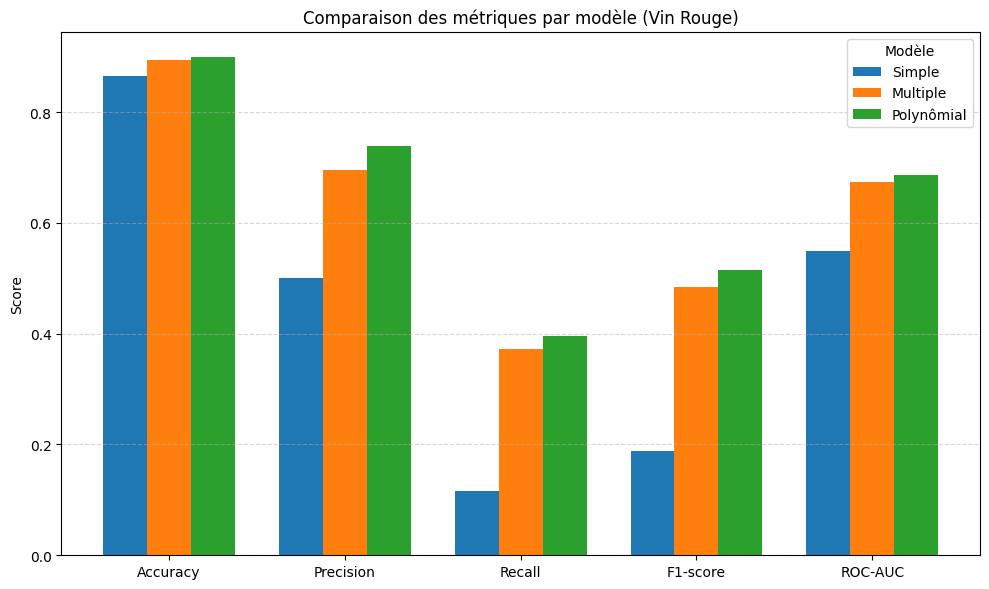

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# 1) Fonction pour calculer les métriques
def get_metrics(y_true, y_pred, name):
    return {
        "Modèle":           name,
        "Accuracy":         round(accuracy_score(y_true, y_pred), 3),
        "Precision":        round(precision_score(y_true, y_pred), 3),
        "Recall":           round(recall_score(y_true, y_pred), 3),
        "F1-score":         round(f1_score(y_true, y_pred), 3),
        "ROC-AUC":          round(roc_auc_score(y_true, y_pred), 3)
    }

# 2) Récupération des métriques
results = [
    get_metrics(y_test_Red, y_pred_simple_Red,   "Simple"),
    get_metrics(y_test_Red, y_pred_multiple_Red, "Multiple"),
    get_metrics(y_test_Red, y_pred_poly_Red,     "Polynômial")
]

# 3) Création du DataFrame et transposition
df = pd.DataFrame(results).set_index("Modèle")
print(df.T)   # Affichage horizontal

# 4) Diagramme à barres groupées
metrics = df.columns.tolist()
models  = df.index.tolist()
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    ax.bar(x + i*width,
           df.loc[model].values,
           width,
           label=model)

# 5) Personnalisation
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Comparaison des métriques par modèle (Vin Rouge)")
ax.legend(title="Modèle")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


On peux ainsi visualiser d’un coup d’œil que le modèle polynômial atteint le meilleur ROC‑AUC (0,687), devant le multiple (0,673) et le simple (0,549). Cela confirme son avantage pour séparer les bonnes et mauvaises qualités de vin rouge.

# Pour le vin blanc

Modèle     Simple  Multiple  Polynômial
Accuracy    0.801     0.801       0.811
Precision   0.596     0.584       0.617
Recall      0.250     0.278       0.335
F1-score    0.352     0.377       0.434
ROC-AUC     0.602     0.612       0.639


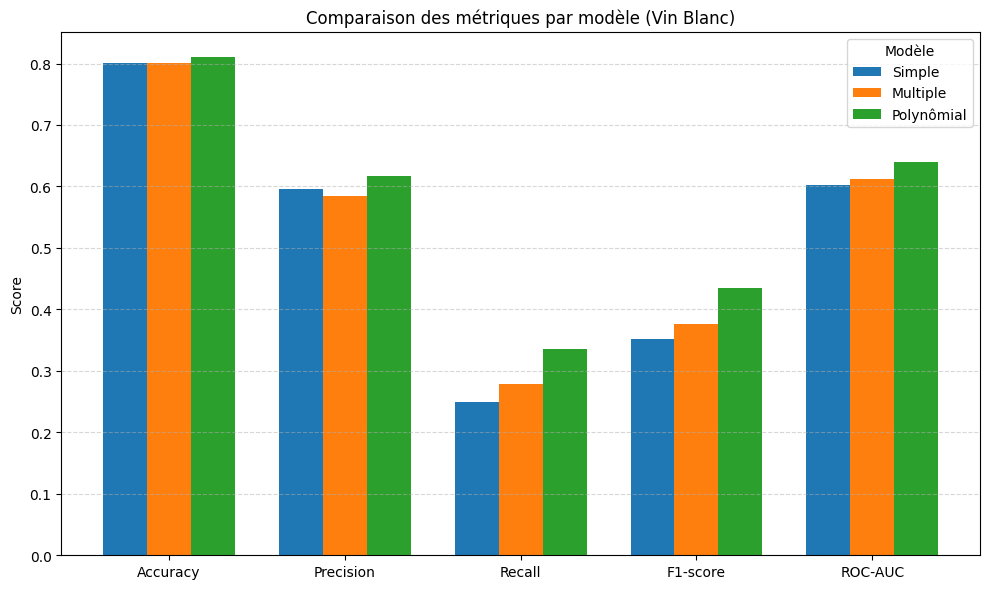

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1) Fonction pour calculer les métriques
def get_metrics(y_true, y_pred, model_name):
    return {
        "Modèle": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall": round(recall_score(y_true, y_pred), 3),
        "F1-score": round(f1_score(y_true, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_true, y_pred), 3)
    }

# 2) Résultats pour les modèles sur les vins blancs
results_white = [
    get_metrics(y_test_White, y_pred_simple_White, "Simple"),
    get_metrics(y_test_White, y_pred_multiple_White, "Multiple"),
    get_metrics(y_test_White, y_pred_poly_White, "Polynômial")
]

# 3) DataFrame
df_white = pd.DataFrame(results_white).set_index("Modèle")
print(df_white.T)  # Affichage horizontal

# 4) Graphique : comparaison groupée
metrics = df_white.columns.tolist()
models = df_white.index.tolist()
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(models):
    ax.bar(x + i * width, df_white.loc[model].values, width, label=model)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Comparaison des métriques par modèle (Vin Blanc)")
ax.legend(title="Modèle")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Le graphique met en évidence une légère amélioration progressive des performances en allant du modèle simple au modèle polynômial.

# 4-2-Visualisation des matrices de confusion et des courbes ROC

# Pour le vin rouge

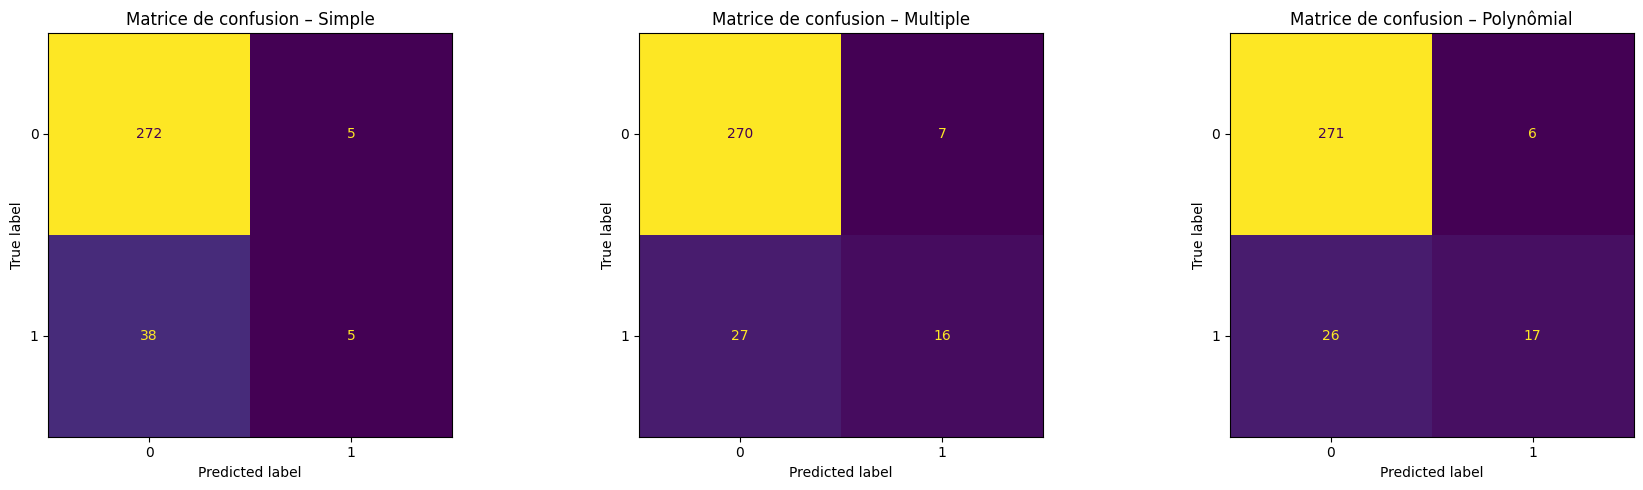

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Liste des prédictions et noms de modèles
models_Red = [
    ("Simple", y_test_Red, y_pred_simple_Red),
    ("Multiple", y_test_Red, y_pred_multiple_Red),
    ("Polynômial", y_test_Red, y_pred_poly_Red)
]

# Création de la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boucle sur chaque modèle
for idx_Red, (name_Red, y_true_Red, y_pred_Red) in enumerate(models_Red):
    ConfusionMatrixDisplay.from_predictions(
        y_true_Red,
        y_pred_Red,
        ax=axes[idx_Red],
        colorbar=False
    )
    axes[idx_Red].set_title(f"Matrice de confusion – {name_Red}")
    axes[idx_Red].grid(False)

plt.tight_layout()
plt.show()


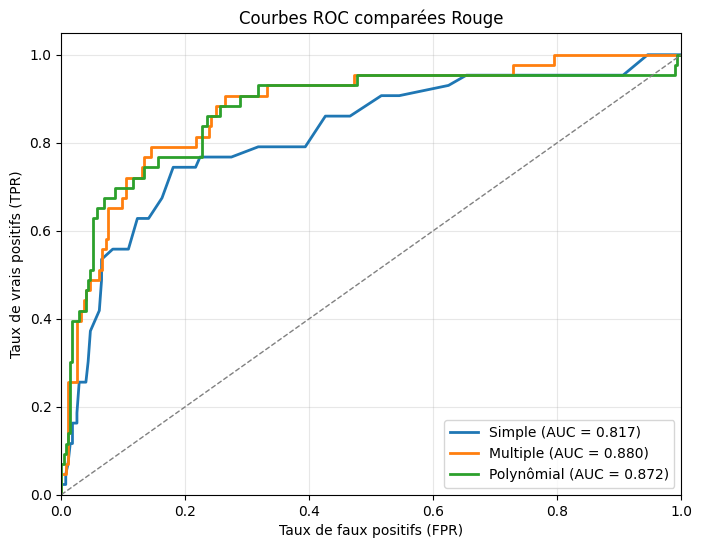

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Préparation du dict pour boucler
models_Red = {
    "Simple": {
        "pipe": pipe_simple_Red,
        "X":   X_test_Red[["alcohol"]]
    },
    "Multiple": {
        "pipe": pipe_multiple_Red,
        "X":    X_test_Red
    },
    "Polynômial": {
        "pipe": pipe_poly_Red,
        "X":    X_test_Red
    }
}

plt.figure(figsize=(8, 6))

for name_Red, info_Red in models_Red.items():
    pipe_Red = info_Red["pipe"]
    X_val_Red = info_Red["X"]
    
    # 1) récupérer les probabilités de la classe positive (1)
    y_score_Red = pipe_Red.predict_proba(X_val_Red)[:, 1]
    
    # 2) calculer FPR, TPR
    fpr_Red, tpr_Red, _ = roc_curve(y_test_Red, y_score_Red)
    roc_auc_Red = auc(fpr_Red, tpr_Red)
    
    # 3) tracer
    plt.plot(fpr_Red, tpr_Red, lw=2,
             label=f"{name_Red} (AUC = {roc_auc_Red:.3f})")

# tracer la diagonale aléatoire
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC comparées Rouge")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


# Pour le vin blanc

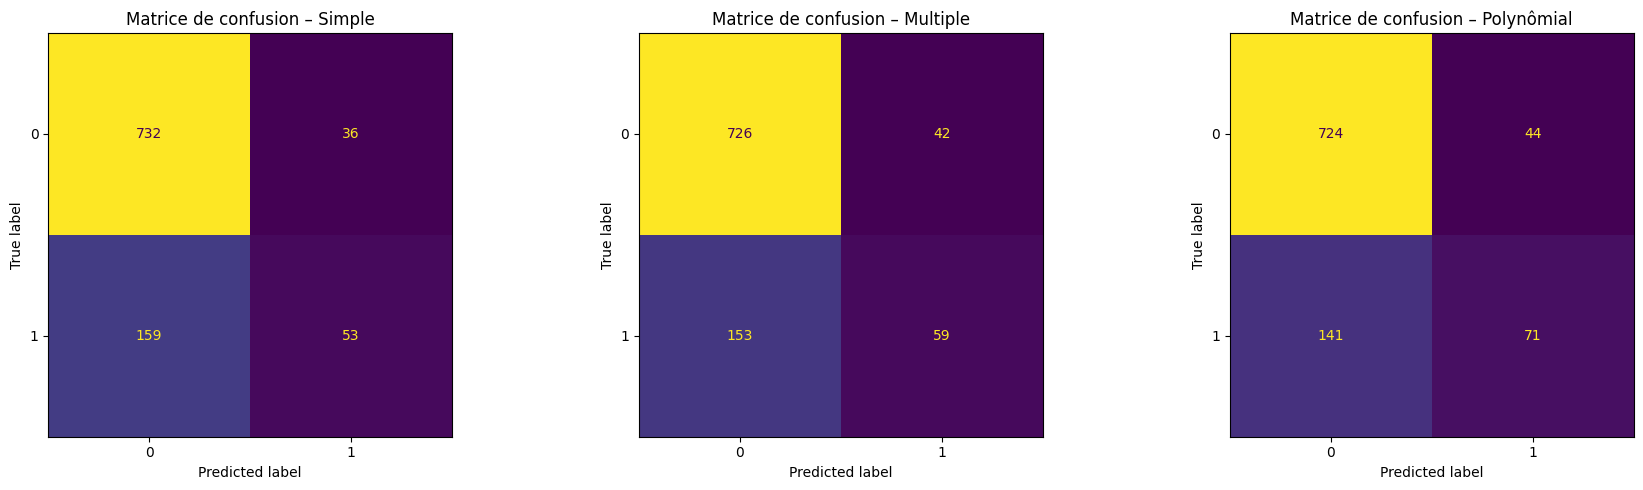

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Liste des prédictions et noms de modèles
models_White = [
    ("Simple", y_test_White, y_pred_simple_White),
    ("Multiple", y_test_White, y_pred_multiple_White),
    ("Polynômial", y_test_White, y_pred_poly_White)
]

# Création de la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boucle sur chaque modèle
for idx_White, (name_White, y_true_White, y_pred_White) in enumerate(models_White):
    ConfusionMatrixDisplay.from_predictions(
        y_true_White,
        y_pred_White,
        ax=axes[idx_White],
        colorbar=False
    )
    axes[idx_White].set_title(f"Matrice de confusion – {name_White}")
    axes[idx_White].grid(False)

plt.tight_layout()
plt.show()


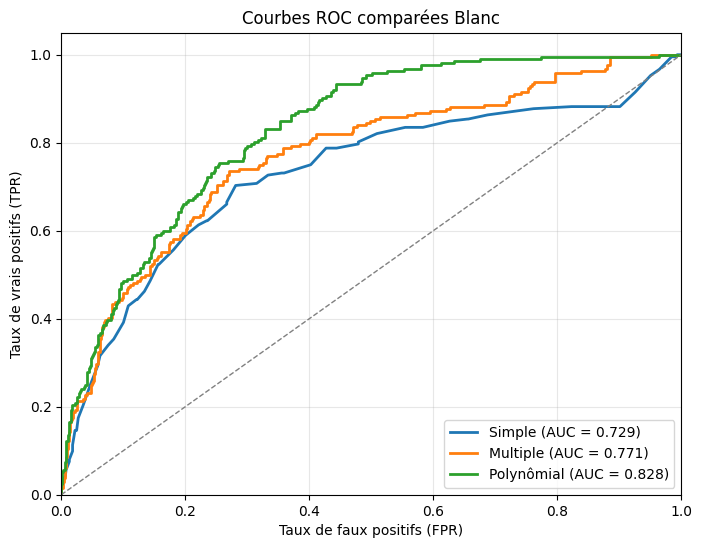

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Préparation du dict pour boucler
models_White = {
    "Simple": {
        "pipe": pipe_simple_White ,
        "X":   X_test_White [["alcohol"]]
    },
    "Multiple": {
        "pipe": pipe_multiple_White ,
        "X":    X_test_White 
    },
    "Polynômial": {
        "pipe": pipe_poly_White ,
        "X":    X_test_White 
    }
}

plt.figure(figsize=(8, 6))

for name, info in models_White .items():
    pipe = info["pipe"]
    X_val = info["X"]
    
    # 1) récupérer les probabilités de la classe positive (1)
    y_score = pipe.predict_proba(X_val)[:, 1]
    
    # 2) calculer FPR, TPR
    fpr, tpr, _ = roc_curve(y_test_White , y_score)
    roc_auc = auc(fpr, tpr)
    
    # 3) tracer
    plt.plot(fpr, tpr, lw=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

# tracer la diagonale aléatoire
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbes ROC comparées Blanc")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


# Tests

# Pour le vin rouge

In [38]:
import pandas as pd
import pickle

# -------------------------------------------------------------
# 1) Charger la pipeline multiple (StandardScaler + LogisticRegression)
path = r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin rouge\pipeline_multiple.mod"
pipe_multiple_red = pickle.load(open(path, "rb"))

# -------------------------------------------------------------
# 2) Définir les caractéristiques d’un nouveau vin rouge à tester
#    (remplace par tes propres valeurs si besoin)
new_red = pd.DataFrame({
    "fixed acidity":        [7.4],
    "volatile acidity":     [0.70],
    "citric acid":          [0.00],
    "residual sugar":       [1.9],
    "chlorides":            [0.076],
    "free sulfur dioxide":  [11.0],
    "total sulfur dioxide": [34.0],
    "density":              [0.9978],
    "pH":                   [3.51],
    "sulphates":            [0.56],
    "alcohol":              [9.4]
})

# -------------------------------------------------------------
# 3) Prédire la classe et la probabilité
classe_predite = pipe_multiple_red.predict(new_red)[0]          # 0 ou 1
proba_bon = pipe_multiple_red.predict_proba(new_red)[0][1]      # proba d’être classe 1

# -------------------------------------------------------------
# 4) Afficher un message lisible
qualite_txt = "BON vin (classe 1)" if classe_predite == 1 else "MAUVAIS vin (classe 0)"
print(f"→ Classe prédite : {classe_predite}  ––>  {qualite_txt}")
print(f"→ Probabilité d’être un bon vin : {proba_bon:.2%}")


→ Classe prédite : 0  ––>  MAUVAIS vin (classe 0)
→ Probabilité d’être un bon vin : 0.74%


# Pour le vin blanc

In [40]:
import pandas as pd
import pickle

# 1. Recharger le pipeline polynômial (vin blanc)
path = r"C:\Users\Admin\Desktop\Projet Personnel\wine+quality\Pipeline vin blanc\pipeline_polynomiale.mod"
pipe_poly_white = pickle.load(open(path, "rb"))

# 2. Définir les caractéristiques du vin blanc à tester
new_white = pd.DataFrame({
    'fixed acidity': [7.0],
    'volatile acidity': [0.27],
    'citric acid': [0.36],
    'residual sugar': [20.7],
    'chlorides': [0.045],
    'free sulfur dioxide': [45.0],
    'total sulfur dioxide': [170.0],
    'density': [1.0010],
    'pH': [3.00],
    'sulphates': [0.45],
    'alcohol': [8.8]
})

# 3. Prédiction
classe = pipe_poly_white.predict(new_white)[0]
proba = pipe_poly_white.predict_proba(new_white)[0][1]

# 4. Résultat
qualite_txt = "BON vin (classe 1)" if classe == 1 else "MAUVAIS vin (classe 0)"
print(f"→ Classe prédite : {classe} —> {qualite_txt}")
print(f"→ Probabilité d’être un bon vin : {proba:.2%}")


→ Classe prédite : 0 —> MAUVAIS vin (classe 0)
→ Probabilité d’être un bon vin : 4.87%
